# LIKWID AMG Power Time Series (All Policies)

Load AMG LIKWID profiles for the same policies as `plot_likwid_profiles_all.ipynb`
and plot time series of L3 power and total power.


In [1]:
# User inputs
benchmark_name = 'specfem3D'
# policy_folders = ['2.25GHz', 'ondemand', 'performance', 'everest', 'DVFS-energy', 'DVFS-energy-update']
# policy_order = ['2.25GHz', 'ondemand', 'performance', 'everest', 'DVFS-energy', 'DVFS-energy-update']

policy_folders = ['everest', 'DVFS-energy-update', 'DVFS-energy-window']
policy_order = ['everest', 'DVFS-energy-update', 'DVFS-energy-window']

skip_initial = 3  # drop first N samples if noisy


In [2]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Sequence

import matplotlib.pyplot as plt
import pandas as pd

SUM_FIELDS = {
    'Energy [J]',
    'Power [W]',
    'Energy PP0 [J]',
    'Power PP0 [W]',
    'Energy DRAM [J]',
    'Power DRAM [W]',
    'Energy PLATFORM [J]',
    'Power PLATFORM [W]',
    'Memory read bandwidth [MBytes/s]',
    'Memory read data volume [GBytes]',
    'Memory write bandwidth [MBytes/s]',
    'Memory write data volume [GBytes]',
    'Memory bandwidth [MBytes/s]',
    'Memory data volume [GBytes]',
    'L3 request rate',
    'L3 miss rate',
    'L3 miss ratio',
    'Energy Core [J]',
    'Power Core [W]',
    'Energy L3 [J]',
    'Power L3 [W]',
}


def extract_job_id(path: Path | str) -> str:
    name = path.name if isinstance(path, Path) else Path(path).name
    parts = name.split('.')
    if len(parts) < 3:
        raise ValueError(f'Could not infer job id from {name}')
    return parts[-2]


def _stdout_candidates(folder: Path, job_id: str) -> List[Path]:
    pattern = f'*.{job_id}.out'
    matches = sorted(folder.rglob(pattern))
    return [
        path
        for path in matches
        if 'timeline' not in path.name and not path.name.startswith('likwid_')
    ]


def find_stdout_for_job(base_dir: Path, job_id: str) -> Path:
    search_roots = [base_dir, base_dir.parent]
    candidates: List[Path] = []
    for root in search_roots:
        if root.exists():
            candidates.extend(_stdout_candidates(root, job_id))
    if not candidates:
        raise FileNotFoundError(f'No stdout file found for job {job_id} under {base_dir.parent}')
    candidates = sorted(candidates)
    return candidates[0]


def parse_headers(stdout_path: Path) -> List[Sequence[str]]:
    headers: List[Sequence[str]] = []
    with stdout_path.open() as handle:
        for line in handle:
            if line.startswith('# GID|'):
                parts = line.lstrip('#').strip().split('|')
                fields = parts[3:]
                if fields:
                    headers.append(fields)
    if not headers:
        raise RuntimeError(f'No LIKWID headers found in {stdout_path}')
    return headers


def aggregate_metric(values: Sequence[float], field: str) -> float:
    if not values:
        raise KeyError(f'Missing values for field {field}')
    if field in SUM_FIELDS:
        return float(sum(values))
    return float(sum(values) / len(values))


def load_likwid_profile(profile_path: Path, stdout_path: Path, *, skip_initial: int = 0) -> pd.DataFrame:
    headers = parse_headers(stdout_path)
    header = headers[0]
    global_field = header[0]
    metric_fields = header[1:]

    rows: List[Dict[str, float]] = []
    with profile_path.open() as handle:
        for raw_line in handle:
            line = raw_line.strip()
            if not line or not line[0].isdigit():
                continue
            parts = line.split(',')
            if len(parts) < 4:
                continue

            gid = int(parts[0])
            metrics_count = int(parts[1])
            cpu_count = int(parts[2])
            values = [float(val) for val in parts[3:]]

            if metrics_count != len(metric_fields):
                raise ValueError(
                    f'Header mismatch: expected {len(metric_fields)} metrics, got {metrics_count} in {profile_path.name}'
                )

            expected_values = 1 + metrics_count * cpu_count
            if len(values) != expected_values:
                raise ValueError(
                    f'Expected {expected_values} numeric entries, got {len(values)} in {profile_path.name}'
                )

            global_value = values[0]
            metric_values = values[1:]
            extracted: Dict[str, float] = {global_field: global_value, 'gid': gid}

            for idx, field in enumerate(metric_fields):
                start = idx * cpu_count
                end = start + cpu_count
                segment = metric_values[start:end]
                if segment:
                    extracted[field] = aggregate_metric(segment, field)

            rows.append(extracted)

    if not rows:
        raise RuntimeError(f'No LIKWID samples parsed from {profile_path.name}')

    if skip_initial:
        rows = rows[skip_initial:]

    df = pd.DataFrame(rows).reset_index(drop=True)
    df.index.name = 'sample_index'
    return df


def list_profiles(profiles_dir: Path) -> pd.DataFrame:
    profile_paths = sorted(profiles_dir.glob('*.prof'))
    profile_table = []
    for path in profile_paths:
        parts = path.stem.split('.')
        name = parts[0].removeprefix('spechpc_')
        job = parts[1] if len(parts) > 1 else ''
        profile_table.append({'benchmark': name, 'job_id': job, 'path': path})
    return pd.DataFrame(profile_table).sort_values(['benchmark', 'job_id'])


def newest_profile_for_benchmark(profiles_df: pd.DataFrame, benchmark: str) -> Path:
    match = profiles_df[profiles_df['benchmark'] == benchmark]
    if match.empty:
        raise ValueError(f'No profiles found for benchmark {benchmark}')
    match = match.sort_values('job_id')
    return Path(match.iloc[-1]['path'])


def build_timeseries_for_policy(base_dir: Path, policy: str, benchmark: str, skip_initial: int) -> pd.DataFrame:
    policy_dir = base_dir / policy
    profiles_dir = policy_dir / 'profiles'
    profiles_df = list_profiles(profiles_dir)
    profile_file = newest_profile_for_benchmark(profiles_df, benchmark)
    job_id = extract_job_id(profile_file)
    stdout_file = find_stdout_for_job(policy_dir, job_id)

    df = load_likwid_profile(profile_file, stdout_file, skip_initial=skip_initial).copy()
    if 'Power Core [W]' not in df.columns or 'Power L3 [W]' not in df.columns:
        raise ValueError(f'Missing required power columns in {profile_file}')

    if 'Total runtime [s]' in df.columns:
        df['time_s'] = df['Total runtime [s]']
    else:
        df['time_s'] = df.index.astype(float)

    df['Total Power [W]'] = df['Power Core [W]'] + df['Power L3 [W]']
    df['policy'] = policy
    return df


def load_policy_timeseries(base_dir: Path, policies: List[str], benchmark: str, skip_initial: int) -> Dict[str, pd.DataFrame]:
    traces: Dict[str, pd.DataFrame] = {}
    for policy in policies:
        traces[policy] = build_timeseries_for_policy(base_dir, policy, benchmark, skip_initial)
    return traces


def remove_outliers_iqr(df: pd.DataFrame, columns: Sequence[str], *, iqr_k: float = 1.5) -> pd.DataFrame:
    if df.empty:
        return df

    mask = pd.Series(True, index=df.index)
    for col in columns:
        if col not in df.columns:
            continue
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        if pd.isna(iqr) or iqr == 0:
            continue
        lower = q1 - iqr_k * iqr
        upper = q3 + iqr_k * iqr
        mask &= df[col].between(lower, upper)

    return df.loc[mask].copy()


def plot_power_timeseries(traces: Dict[str, pd.DataFrame], policy_order: List[str] | None = None) -> None:
    order = policy_order if policy_order is not None else list(traces.keys())

    fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

    for policy in order:
        if policy not in traces:
            continue
        df = remove_outliers_iqr(traces[policy], ['Power L3 [W]', 'Total Power [W]', 'Clock [MHz]'])
        if df.empty:
            continue
        axes[0].plot(df['time_s'], df['Power L3 [W]'], label=policy, linewidth=1.7)
        axes[1].plot(df['time_s'], df['Total Power [W]'], label=policy, linewidth=1.7)
        if 'Clock [MHz]' in df.columns:
            axes[2].plot(df['time_s'], df['Clock [MHz]'], label=policy, linewidth=1.7)

    axes[0].set_title('L3 Power Time Series')
    axes[0].set_ylabel('Power L3 [W]')
    axes[0].grid(True, alpha=0.3)

    axes[1].set_title('Total Power Time Series')
    axes[1].set_ylabel('Total Power [W]')
    axes[1].grid(True, alpha=0.3)

    axes[2].set_title('Clock Time Series')
    axes[2].set_xlabel('Time [s]')
    axes[2].set_ylabel('Clock [MHz]')
    axes[2].grid(True, alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title='Policy', loc='center left', bbox_to_anchor=(1.01, 0.5))
    plt.tight_layout(rect=[0, 0, 0.84, 1])
    plt.show()


In [3]:
base_dir = Path.cwd()
traces = load_policy_timeseries(base_dir, policy_folders, benchmark_name, skip_initial)
pd.DataFrame({
    'policy': list(traces.keys()),
    'samples': [len(traces[p]) for p in traces],
    'runtime_end_s': [float(traces[p]['time_s'].iloc[-1]) for p in traces],
})


,policy,samples,runtime_end_s
0,everest,1507,756.511821
1,DVFS-energy-update,1268,636.199233
2,DVFS-energy-window,1262,633.201786


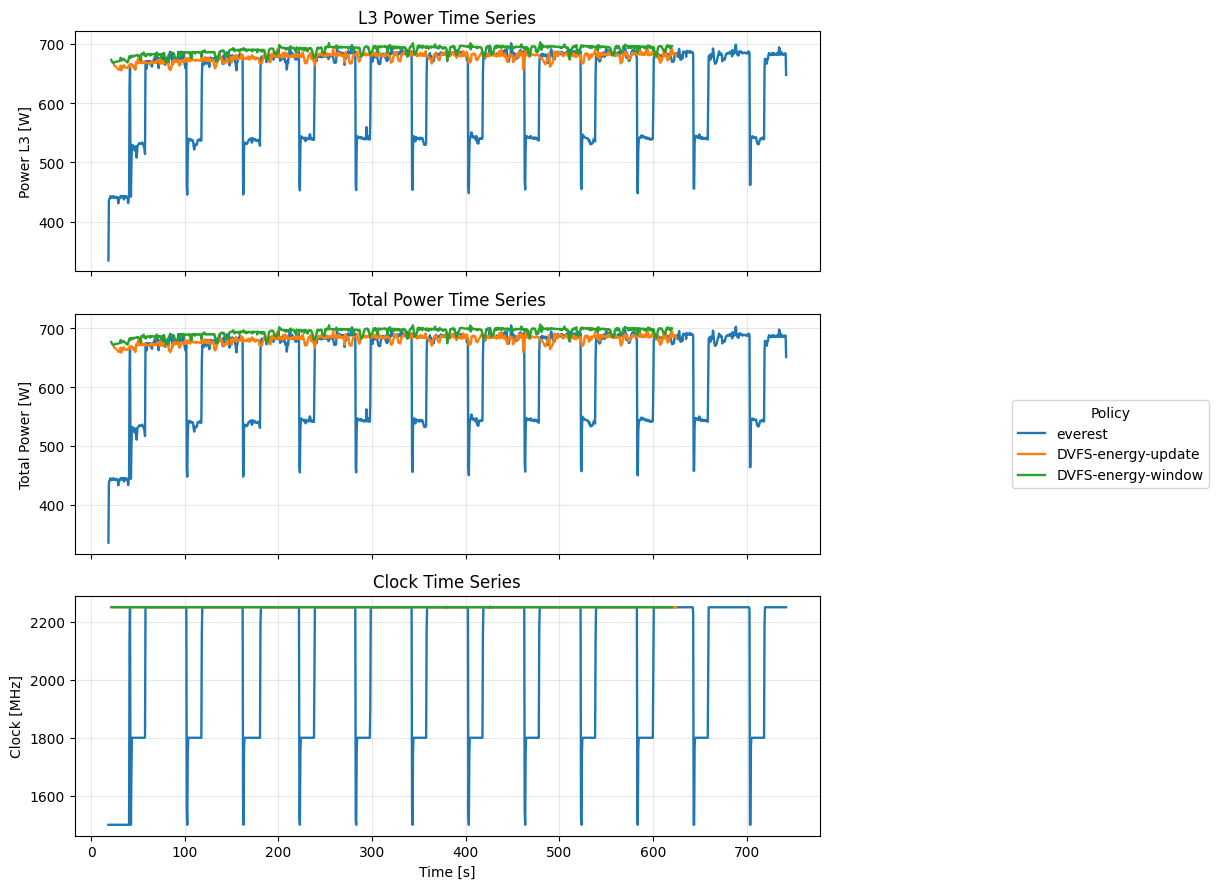

In [4]:
plot_power_timeseries(traces, policy_order)
